# Chapter 4: Step 4 — Model Diagnosis and Tuning

**Course:** Supervised Machine Learning  
**Source:** *Mastering Machine Learning with Python in Six Steps* — Manohar Swamynathan (2019)  
**Book pages:** 263–323 (PDF pages 277–337)

---

## Welcome!

Chapter 4 is about making models **work better in practice**: tuning probability cutoffs for imbalanced data, cross-validation, ensemble methods (bagging, boosting, voting, stacking), hyperparameter search, and sensor denoising.

**How to use this notebook:**
1. Run cells **top to bottom**.
2. Read each markdown block — it explains *why* the listing matters and *what to notice* in the output.
3. Listings 4-1 through 4-25 from the book are included with Python 3 / modern scikit-learn fixes.


## Shared Setup

Loads libraries, sets `DATA_DIR` to the course `Data/` folder (`Diabetes.csv`, `digit.csv`, `Temperature.csv`), and defines helpers used in ensemble visualization listings.

**Optional packages:** `imbalanced-learn`, `xgboost`, `mlxtend`, `bayesian-optimization`, `PyWavelets` — listings that need them include install hints or sklearn fallbacks.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

from sklearn import metrics, model_selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              ExtraTreesClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, VotingClassifier)

DATA_DIR = Path('Data')

try:
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print('pip install imbalanced-learn  # needed for Listings 4-5 and 4-6')

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('pip install xgboost  # needed for Listings 4-17 and 4-18')

try:
    from mlxtend.classifier import EnsembleVoteClassifier
    HAS_MLXTEND = True
except ImportError:
    HAS_MLXTEND = False


def plot_decision_regions(X, y, classifier, h=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(X[y == cl, 0], X[y == cl, 1], alpha=0.8, c=cmap(idx),
                    marker=markers[idx], label=cl)

print('Setup complete. DATA_DIR:', DATA_DIR.resolve())


pip install xgboost  # needed for Listings 4-17 and 4-18
Setup complete. DATA_DIR: D:\Gurinder Data HardDrive\CIMT College\Course_11_Supervised Machine Learning\Supervised_Machine_Learning\Data


---

## Optimal Probability Cutoff

When classes are imbalanced, the default 0.5 threshold is often wrong. We find a cutoff that balances true positives and false positives using the ROC curve.


### Listing 4-1. Load Data and Check the Class Distribution

**Class imbalance check** on the Pima Indians diabetes dataset. Only ~35% of patients tested positive — so a default 0.5 probability cutoff may not be optimal.

**Look for:** class proportions printed as fractions summing to 1.


In [2]:
df = pd.read_csv(str(DATA_DIR / 'Diabetes.csv'))
print(df.head())
print(df['class'].value_counts(normalize=True))
X = df.iloc[:, :8]
y = df['class']


   preg_count  glucose_concentration  blood_pressure  skin_thickness  \
0           6                    148              72              35   
1           1                     85              66              29   
2           8                    183              64               0   
3           1                     89              66              23   
4           0                    137              40              35   

   serum_insulin   bmi  pedigree_function  age  class  
0              0  33.6              0.627   50      1  
1              0  26.6              0.351   31      0  
2              0  23.3              0.672   32      1  
3             94  28.1              0.167   21      0  
4            168  43.1              2.288   33      1  
class
0    0.651042
1    0.348958
Name: proportion, dtype: float64


### Listing 4-2. Build a Logistic Regression Model and Evaluate the Performance

We fit **logistic regression** with the traditional **0.5 cutoff** (predict probability > 0.5 → diabetic). This is the baseline before tuning the threshold.

**Look for:** training accuracy around 0.75–0.78.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = model.predict(X_train)
probs = model.predict_proba(X_train)
y_pred_prob = probs[:, 1]
print('Accuracy:', metrics.accuracy_score(y_train, y_pred))


Accuracy: 0.7653631284916201


### Listing 4-3. Find Optimal Cutoff Point

The **ROC curve** plots True Positive Rate vs False Positive Rate at every threshold. The optimal cutoff sits where TPR is high and FPR is low — geometrically where `tpr ≈ 1 - fpr`.

**Look for:** AUC near 0.83; the gap between the TPR and (1−FPR) curves.


Area under the ROC curve: 0.8375161552102433
Near-optimal row:
         tpr     1-fpr        tf  thresholds
86  0.752577  0.749271  0.003306    0.340459


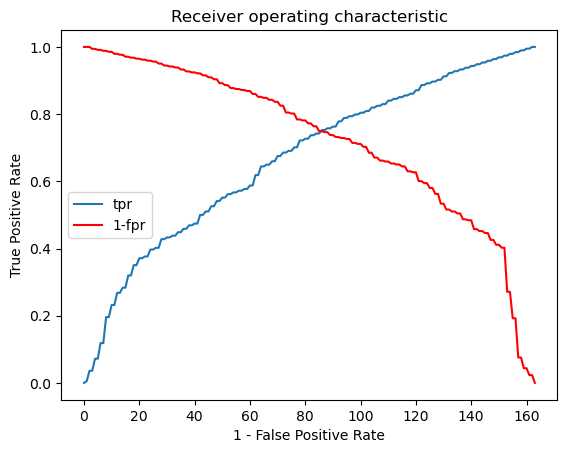

In [4]:
fpr, tpr, thresholds = metrics.roc_curve(y_train, y_pred_prob)
roc_auc = metrics.auc(fpr, tpr)
print('Area under the ROC curve:', roc_auc)

i = np.arange(len(tpr))
roc = pd.DataFrame({'tpr': tpr, '1-fpr': 1 - fpr, 'tf': tpr - (1 - fpr), 'thresholds': thresholds}, index=i)
print('Near-optimal row:')
print(roc.iloc[(roc['tf'] - 0).abs().argsort()[:1]])

plt.plot(roc['tpr'], label='tpr')
plt.plot(roc['1-fpr'], color='red', label='1-fpr')
plt.legend(loc='best')
plt.xlabel('1 - False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()


### Listing 4-4. A Function for Finding Optimal Probability Cutoff

**Optimal cutoff function** searches thresholds along the ROC curve for the point where `tpr - (1-fpr)` is closest to zero. Compare confusion matrices before and after.

**Look for:** improved recall for the minority (diabetic) class even when overall accuracy stays similar.


In [5]:
def find_optimal_cutoff(target, predicted):
    fpr, tpr, threshold = metrics.roc_curve(target, predicted)
    roc = pd.DataFrame({'tf': tpr - (1 - fpr), 'threshold': threshold})
    return float(roc.iloc[(roc['tf'] - 0).abs().argsort()[:1]]['threshold'].values[0])

threshold = find_optimal_cutoff(y_train, y_pred_prob)
print('Optimal Probability Threshold:', threshold)
y_pred_optimal = np.where(y_pred_prob >= threshold, 1, 0)
print('\nNormal - Accuracy:', metrics.accuracy_score(y_train, y_pred))
print('Optimal Cutoff - Accuracy:', metrics.accuracy_score(y_train, y_pred_optimal))
print('\nNormal - Confusion Matrix:\n', metrics.confusion_matrix(y_train, y_pred))
print('Optimal - Cutoff Confusion Matrix:\n', metrics.confusion_matrix(y_train, y_pred_optimal))


Optimal Probability Threshold: 0.3404590485305675

Normal - Accuracy: 0.7653631284916201
Optimal Cutoff - Accuracy: 0.750465549348231

Normal - Confusion Matrix:
 [[297  46]
 [ 80 114]]
Optimal - Cutoff Confusion Matrix:
 [[257  86]
 [ 48 146]]


---

## Imbalanced Data Handling

Rare events (fraud, disease) create skewed classes. **Resampling** adjusts training data before fitting.


### Listing 4-5. Rare Event or Imbalanced Data Handling

Synthetic **imbalanced data** (90% class 0, 10% class 1) demonstrates three resampling strategies: **undersampling**, **oversampling**, and **SMOTE** (Synthetic Minority Over-sampling).

**Look for:** scatter plots showing how each method rebalances the two classes.


Positive class: 514
Negative class: 4486


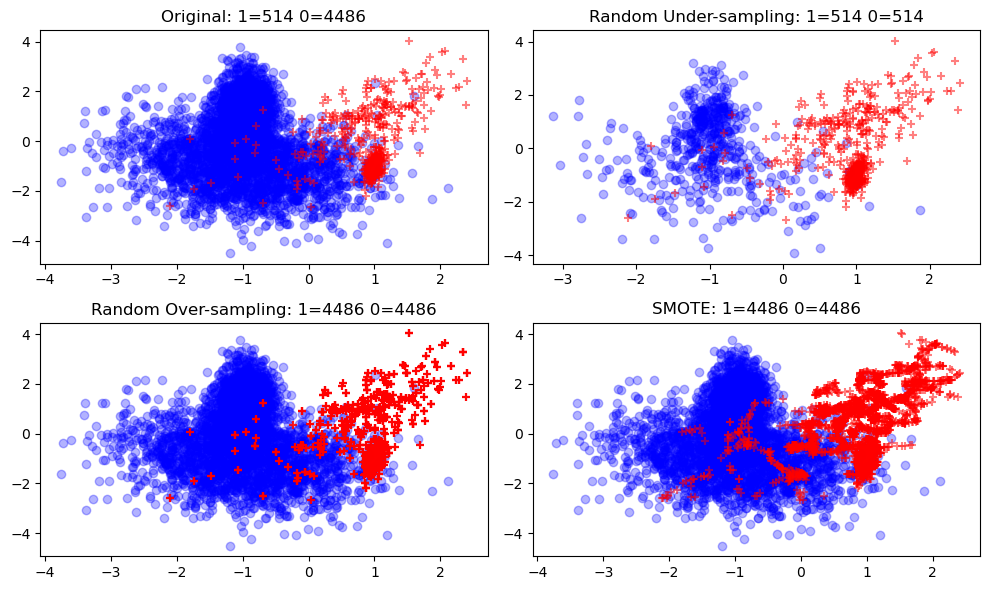

In [6]:
from sklearn.datasets import make_classification

if not HAS_IMBLEARN:
    raise ImportError('Install imbalanced-learn: pip install imbalanced-learn')

X, y = make_classification(n_samples=5000, n_features=2, n_informative=2, n_redundant=0,
                           weights=[0.9, 0.1], random_state=2017)
print('Positive class:', (y == 1).sum())
print('Negative class:', (y == 0).sum())

X_RUS, y_RUS = RandomUnderSampler(random_state=2017).fit_resample(X, y)
X_ROS, y_ROS = RandomOverSampler(random_state=2017).fit_resample(X, y)
X_SMOTE, y_SMOTE = SMOTE(random_state=2017).fit_resample(X, y)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, (Xd, yd, title) in zip(axes.ravel(), [
    (X, y, 'Original'),
    (X_RUS, y_RUS, 'Random Under-sampling'),
    (X_ROS, y_ROS, 'Random Over-sampling'),
    (X_SMOTE, y_SMOTE, 'SMOTE')]):
    ax.scatter(Xd[yd == 0, 0], Xd[yd == 0, 1], marker='o', color='blue', alpha=0.3)
    ax.scatter(Xd[yd == 1, 0], Xd[yd == 1, 1], marker='+', color='red', alpha=0.5)
    ax.set_title(f"{title}: 1={(yd == 1).sum()} 0={(yd == 0).sum()}")
plt.tight_layout()
plt.show()


### Listing 4-6. Build Models on Various Resampling Methods and Evaluate Performance

We train the same **decision tree** on each resampled dataset and compare **ROC-AUC**. SMOTE often generalizes better than naive oversampling on test data.

**Look for:** test AUC for SMOTE vs RUS/ROS.


In [7]:
from sklearn import tree

splits = [
    ('RUS', *train_test_split(X_RUS, y_RUS, test_size=0.3, random_state=2017)),
    ('ROS', *train_test_split(X_ROS, y_ROS, test_size=0.3, random_state=2017)),
    ('SMOTE', *train_test_split(X_SMOTE, y_SMOTE, test_size=0.3, random_state=2017)),
]
for name, Xtr, Xte, ytr, yte in splits:
    clf = tree.DecisionTreeClassifier(random_state=2017).fit(Xtr, ytr)
    print(f"\n{name} - Train AUC:", metrics.roc_auc_score(ytr, clf.predict(Xtr)))
    print(f"{name} - Test AUC:", metrics.roc_auc_score(yte, clf.predict(Xte)))



RUS - Train AUC: 1.0
RUS - Test AUC: 0.9419191919191919

ROS - Train AUC: 1.0
ROS - Test AUC: 0.988441461595824

SMOTE - Train AUC: 1.0
SMOTE - Test AUC: 0.946894089555007


---

## Cross-Validation

Single train/test splits can be lucky or unlucky. **K-fold CV** and **stratified K-fold** give more trustworthy performance estimates.


### Listing 4-7. K-fold Cross-Validation

**K-fold cross-validation** splits training data into k folds; each fold serves once as validation. More reliable than a single train/test split.

**Look for:** per-fold train/test accuracy printed for 5 folds.


In [8]:
df = pd.read_csv(str(DATA_DIR / 'Diabetes.csv'))
X = StandardScaler().fit_transform(df.iloc[:, :8].values)
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2017)
clf = LogisticRegression(max_iter=1000, random_state=2017).fit(X_train, y_train)
print('Train Score:', clf.score(X_train, y_train))
print('Test Score:', clf.score(X_test, y_test))

train_scores = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=5)
test_scores = cross_val_score(clf, X_test, y_test, scoring='accuracy', cv=5)
print('Train CV scores:', train_scores, 'mean:', train_scores.mean())
print('Test CV scores:', test_scores, 'mean:', test_scores.mean())


Train Score: 0.7728119180633147
Test Score: 0.7922077922077922
Train CV scores: [0.80555556 0.73148148 0.81308411 0.76635514 0.71028037] mean: 0.7653513326410523
Test CV scores: [0.85106383 0.7826087  0.80434783 0.76086957 0.7826087 ] mean: 0.7962997224791859


### Listing 4-8. Stratified K-fold Cross-Validation

**Stratified K-fold** preserves class proportions in each fold — important for imbalanced data like diabetes.

**Look for:** similar class distribution noted in each fold's `Class dist.` line.


In [9]:
kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=2019)
train_scores, test_scores = [], []
for k, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), start=1):
    clf.fit(X_train[train_idx], y_train[train_idx])
    tr = clf.score(X_train[train_idx], y_train[train_idx])
    te = clf.score(X_train[val_idx], y_train[val_idx])
    train_scores.append(tr)
    test_scores.append(te)
    print(f'Fold {k}, Class dist.: {np.bincount(y_train[train_idx])}, Train: {tr:.3f}, Val: {te:.3f}')
print('\nTrain CV accuracy:', np.mean(train_scores))
print('Val CV accuracy:', np.mean(test_scores))


Fold 1, Class dist.: [277 152], Train: 0.769, Val: 0.750
Fold 2, Class dist.: [277 152], Train: 0.783, Val: 0.750
Fold 3, Class dist.: [278 152], Train: 0.756, Val: 0.850
Fold 4, Class dist.: [278 152], Train: 0.781, Val: 0.720
Fold 5, Class dist.: [278 152], Train: 0.779, Val: 0.720

Train CV accuracy: 0.7737453244429988
Val CV accuracy: 0.757943925233645


### Listing 4-9. Plotting the ROC Curve for Stratified K-fold Cross-Validation

We plot **ROC curves for each CV fold** and the mean ROC — visual proof that model performance is stable across folds.

**Look for:** five colored fold curves and a dashed mean ROC line.


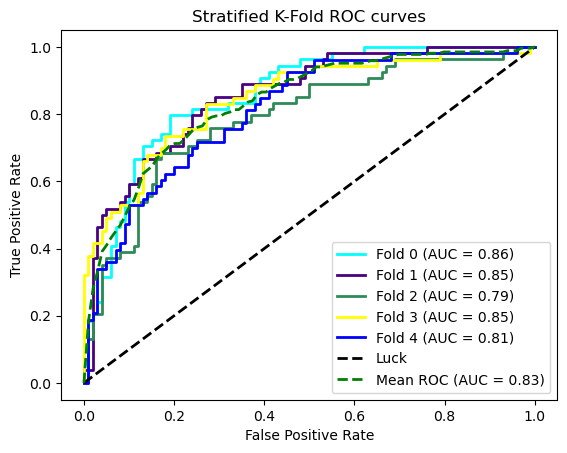

In [10]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from numpy import interp

kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=2019)
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = 0.0
colors = cycle(['cyan', 'indigo', 'seagreen', 'yellow', 'blue'])
for i, ((train, test), color) in enumerate(zip(kfold.split(X, y), colors)):
    probas = clf.fit(X[train], y[train]).predict_proba(X[test])
    fpr, tpr, _ = roc_curve(y[test], probas[:, 1])
    mean_tpr += interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'Fold {i} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Luck')
mean_tpr /= kfold.get_n_splits(X, y)
mean_tpr[-1] = 1.0
plt.plot(mean_fpr, mean_tpr, 'g--', lw=2, label=f'Mean ROC (AUC = {auc(mean_fpr, mean_tpr):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stratified K-Fold ROC curves')
plt.legend(loc='lower right')
plt.show()


---

## Ensemble Methods — Bagging

**Bootstrap aggregation** trains many models on random subsets of data and aggregates predictions to reduce variance.


In [11]:
from sklearn.decomposition import PCA

df = pd.read_csv(str(DATA_DIR / 'Diabetes.csv'))
X = StandardScaler().fit_transform(df.iloc[:, :8].values)
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2019)
kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=2019)
num_trees = 100
clf_DT = DecisionTreeClassifier(random_state=2017).fit(X_train, y_train)
results = cross_val_score(clf_DT, X_train, y_train, cv=kfold)
print('Decision Tree (stand alone) - CV Train:', results.mean())
print('Decision Tree (stand alone) - Test:', metrics.accuracy_score(clf_DT.predict(X_test), y_test))

clf_DT_Bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=2017),
                               n_estimators=num_trees, random_state=2019).fit(X_train, y_train)
results = cross_val_score(clf_DT_Bag, X_train, y_train, cv=kfold)
print('\nDecision Tree (Bagging) - CV Train:', results.mean())
print('Decision Tree (Bagging) - Test:', metrics.accuracy_score(clf_DT_Bag.predict(X_test), y_test))


Decision Tree (stand alone) - CV Train: 0.6954418232706917


Decision Tree (stand alone) - Test: 0.6428571428571429



Decision Tree (Bagging) - CV Train: 0.7410902305744369
Decision Tree (Bagging) - Test: 0.8051948051948052


### Listing 4-10. Stand-Alone Decision Tree vs. Bagging

**Bagging** trains many decision trees on bootstrap samples and averages votes, reducing variance. Compare standalone tree vs 100-tree bagged model.

**Look for:** bagging test accuracy ≥ standalone tree.


In [12]:
# Results printed in the cell above (Listing 4-10).


### Listing 4-11. Decision Tree Feature Importance Function

**Feature importance** from a decision tree shows which inputs (glucose, BMI, etc.) drive splits. Values are scaled relative to the most important feature.

**Look for:** horizontal bar chart — `glucose` and `mass` usually rank high.


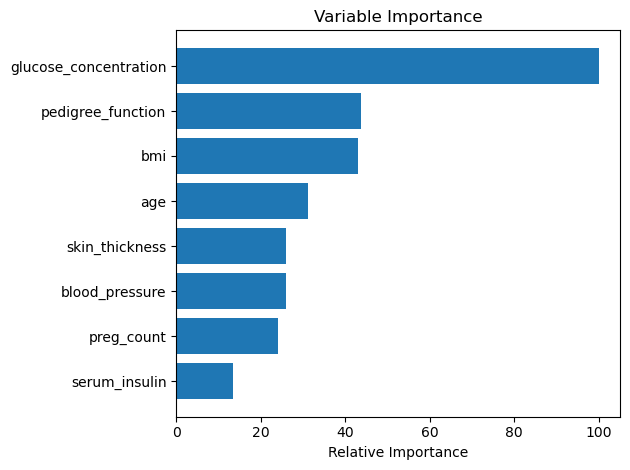

In [13]:
feature_importance = 100.0 * (clf_DT.feature_importances_ / clf_DT.feature_importances_.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, df.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Variable Importance')
plt.tight_layout()
plt.show()


### Listing 4-12. RandomForest Classifier

**Random Forest** bagging uses random feature subsets at each split, decorrelating trees further than plain bagging.

**Look for:** CV train and hold-out test accuracy.


In [14]:
clf_RF = RandomForestClassifier(n_estimators=num_trees, random_state=2019).fit(X_train, y_train)
results = cross_val_score(clf_RF, X_train, y_train, cv=kfold)
print('Random Forest - CV Train:', results.mean())
print('Random Forest - Test:', metrics.accuracy_score(clf_RF.predict(X_test), y_test))


Random Forest - CV Train: 0.7622417699586832
Random Forest - Test: 0.8181818181818182


### Listing 4-13. Extremely Randomized Trees (ExtraTree)

**Extra Trees** adds more randomness by choosing split thresholds randomly — often faster and sometimes more robust.

**Look for:** comparable or better test score vs Random Forest.


In [15]:
clf_ET = ExtraTreesClassifier(n_estimators=num_trees, random_state=2019).fit(X_train, y_train)
results = cross_val_score(clf_ET, X_train, y_train, cv=kfold)
print('ExtraTree - CV Train:', results.mean())
print('ExtraTree - Test:', metrics.accuracy_score(clf_ET.predict(X_test), y_test))


ExtraTree - CV Train: 0.7557377049180328
ExtraTree - Test: 0.8181818181818182


### Listing 4-14. Plot the Decision Boundaries

After **PCA** to 2 dimensions, we visualize **decision boundaries** for tree, bagging, RF, and Extra Trees side by side.

**Look for:** smoother boundaries as ensemble complexity increases.


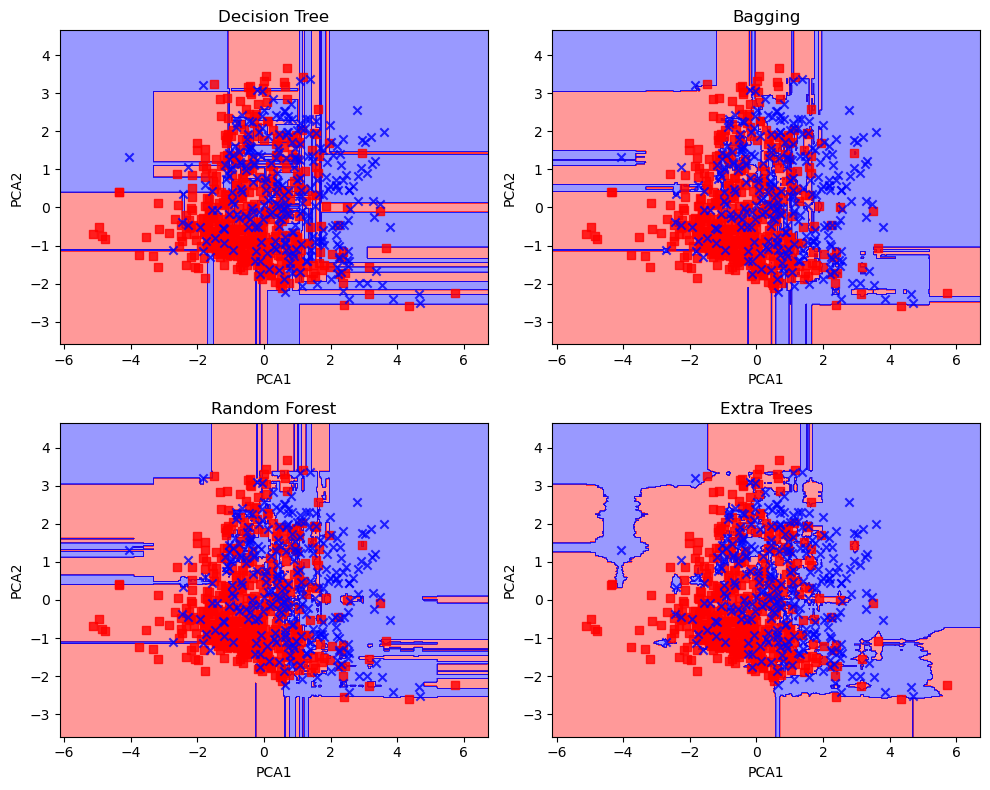

In [16]:
X2 = PCA(n_components=2).fit_transform(X)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=2019)
kfold2 = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=2019)
dt = DecisionTreeClassifier(random_state=2019).fit(X_train2, y_train2)
bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=2019), n_estimators=num_trees,
                        random_state=2019).fit(X_train2, y_train2)
rf = RandomForestClassifier(n_estimators=num_trees, random_state=2019).fit(X_train2, y_train2)
et = ExtraTreesClassifier(n_estimators=num_trees, random_state=2019).fit(X_train2, y_train2)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, mdl, title in zip(axes.ravel(), [dt, bag, rf, et],
                          ['Decision Tree', 'Bagging', 'Random Forest', 'Extra Trees']):
    plt.sca(ax)
    plot_decision_regions(X2, y, mdl)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
plt.tight_layout()
plt.show()


---

## Ensemble Methods — Boosting

Boosting builds models sequentially, each one correcting the errors of the previous ensemble.


In [17]:
df = pd.read_csv(str(DATA_DIR / 'Diabetes.csv'))
X = StandardScaler().fit_transform(df[['age', 'serum_insulin']].values)
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2017)
kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=2017)
num_trees = 100
clf_DT = DecisionTreeClassifier(max_depth=1, random_state=2017).fit(X_train, y_train)
results = cross_val_score(clf_DT, X_train, y_train, cv=kfold)
print('Decision Tree - CV Train: %.2f' % results.mean())
print('Decision Tree - Test: %.2f' % metrics.accuracy_score(clf_DT.predict(X_test), y_test))

clf_DT_Boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=2017),
                                  n_estimators=num_trees, learning_rate=0.1, random_state=2017).fit(X_train, y_train)
results = cross_val_score(clf_DT_Boost, X_train, y_train, cv=kfold)
print('\nAdaBoost - CV Train: %.2f' % results.mean())
print('AdaBoost - Test: %.2f' % metrics.accuracy_score(clf_DT_Boost.predict(X_test), y_test))


Decision Tree - CV Train: 0.64
Decision Tree - Test: 0.65



AdaBoost - CV Train: 0.69
AdaBoost - Test: 0.71


### Listing 4-15. Stand-Alone Decision Tree vs. AdaBoost

**AdaBoost** sequentially trains weak learners (stumps, `max_depth=1`), up-weighting misclassified points each round.

**Look for:** AdaBoost test accuracy vs shallow standalone tree on weak features (`age`, `serum_insulin`).


In [18]:
# AdaBoost results printed in setup cell above.


### Listing 4-16. Gradient Boosting Classifier

**Gradient Boosting** fits each new tree to the **residual errors** of the ensemble — a powerful sequential boosting method.

**Look for:** train vs test accuracy gap (overfitting signal).


In [19]:
clf_GBT = GradientBoostingClassifier(n_estimators=num_trees, learning_rate=0.1, random_state=2017).fit(X_train, y_train)
results = cross_val_score(clf_GBT, X_train, y_train, cv=kfold)
print('Gradient Boosting - CV Train: %.2f' % results.mean())
print('Gradient Boosting - Test: %.2f' % metrics.accuracy_score(clf_GBT.predict(X_test), y_test))


Gradient Boosting - CV Train: 0.68
Gradient Boosting - Test: 0.66


### Listing 4-17. xgboost Classifier Using sklearn Wrapper

**XGBoost** via scikit-learn wrapper with early stopping on a validation set prevents over-training.

**Look for:** CV train and test accuracy; requires `pip install xgboost` if missing.


In [20]:
if not HAS_XGB:
    print('Skipping — install xgboost: pip install xgboost')
else:
    clf_XGB = XGBClassifier(n_estimators=num_trees, objective='binary:logistic',
                            random_state=2019, eval_metric='logloss')
    clf_XGB.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    results = cross_val_score(clf_XGB, X_train, y_train, cv=kfold)
    print('XGBoost - CV Train: %.2f' % results.mean())
    print('XGBoost - Test: %.2f' % metrics.accuracy_score(clf_XGB.predict(X_test), y_test))


Skipping — install xgboost: pip install xgboost


### Listing 4-18. xgboost Using Its Native Python Package Code

Native **XGBoost DMatrix API** with `xgb.cv` finds the optimal number of boosting rounds automatically.

**Look for:** optimal tree count printed from cross-validation.


In [21]:
if not HAS_XGB:
    print('Skipping — install xgboost')
else:
    xgtrain = xgb.DMatrix(X_train, label=y_train)
    xgtest = xgb.DMatrix(X_test, label=y_test)
    param = {'max_depth': 3, 'objective': 'binary:logistic', 'eval_metric': 'logloss'}
    cv_results = xgb.cv(param, xgtrain, num_boost_round=num_trees, nfold=5,
                        stratified=True, early_stopping_rounds=20, seed=2017)
    best_rounds = len(cv_results)
    print('Optimal number of trees:', best_rounds)
    clf_xgb = xgb.train(param, xgtrain, best_rounds)
    y_test_pred = (clf_xgb.predict(xgtest) > 0.5).astype(int)
    print('XGB native - Test: %.2f' % metrics.accuracy_score(y_test_pred, y_test))


Skipping — install xgboost


---

## Ensemble Voting and Stacking

Combine diverse models — **voting** merges predictions directly; **stacking** learns how to blend them.


### Listing 4-19. Ensemble Model

We benchmark **eight classifiers** with 5-fold CV on diabetes data — logistic regression, RF, SVM, kNN, tree, AdaBoost, bagging, and gradient boosting.

**Look for:** which models score highest on CV vs test.


In [22]:
df = pd.read_csv(str(DATA_DIR / 'Diabetes.csv'))
X = df.iloc[:, :8]
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2017)

models = [
    (LogisticRegression(max_iter=1000, random_state=2017), 'Logistic Regression'),
    (RandomForestClassifier(n_estimators=100, random_state=2017), 'Random Forest'),
    (GradientBoostingClassifier(n_estimators=100, random_state=2017), 'Gradient Boosting'),
]
print('5-fold cross validation (top 3 models):\n')
for clf, label in models:
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    clf.fit(X_train, y_train)
    print('Train CV Accuracy: %0.2f (+/- %0.2f) [%s]' % (scores.mean(), scores.std(), label))
    print('Test Accuracy: %0.2f\n' % metrics.accuracy_score(clf.predict(X_test), y_test))


5-fold cross validation (top 3 models):

Train CV Accuracy: 0.76 (+/- 0.04) [Logistic Regression]
Test Accuracy: 0.79



Train CV Accuracy: 0.74 (+/- 0.03) [Random Forest]
Test Accuracy: 0.78



Train CV Accuracy: 0.74 (+/- 0.04) [Gradient Boosting]
Test Accuracy: 0.79



### Listing 4-20. Ensemble Voting Model

**Voting ensemble** combines logistic regression, random forest, and gradient boosting via hard votes (majority class) or soft votes (average probability).

**Look for:** whether voting beats the best single model on test accuracy.


In [23]:
LR = LogisticRegression(max_iter=1000, random_state=2017)
RF = RandomForestClassifier(n_estimators=100, random_state=2017)
GBC = GradientBoostingClassifier(n_estimators=100, random_state=2017)

if HAS_MLXTEND:
    for clf, label in [(EnsembleVoteClassifier(clfs=[LR, RF, GBC], voting='hard'), 'Hard Voting'),
                       (EnsembleVoteClassifier(clfs=[LR, RF, GBC], voting='soft', weights=[1, 1, 1]), 'Soft Voting')]:
        scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
        clf.fit(X, y)
        print('Train CV Accuracy: %0.2f (+/- %0.2f) [%s]' % (scores.mean(), scores.std(), label))
        print('Test Accuracy: %0.2f\n' % metrics.accuracy_score(clf.predict(X_test), y_test))
else:
    vote_hard = VotingClassifier(estimators=[('lr', LR), ('rf', RF), ('gb', GBC)], voting='hard')
    vote_soft = VotingClassifier(estimators=[('lr', LR), ('rf', RF), ('gb', GBC)], voting='soft')
    for clf, label in [(vote_hard, 'Hard Voting (sklearn)'), (vote_soft, 'Soft Voting (sklearn)')]:
        scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
        clf.fit(X_train, y_train)
        print('Train CV Accuracy: %0.2f (+/- %0.2f) [%s]' % (scores.mean(), scores.std(), label))
        print('Test Accuracy: %0.2f\n' % metrics.accuracy_score(clf.predict(X_test), y_test))


Train CV Accuracy: 0.76 (+/- 0.02) [Hard Voting (sklearn)]
Test Accuracy: 0.80



Train CV Accuracy: 0.76 (+/- 0.03) [Soft Voting (sklearn)]
Test Accuracy: 0.78



### Listing 4-21. Model Stacking

**Stacking** trains base models, uses their predicted probabilities as features for a **meta-model** (logistic regression).

**Look for:** meta-model test accuracy vs base learners.


In [24]:
seed = 2019
np.random.seed(seed)
df = pd.read_csv(str(DATA_DIR / 'Diabetes.csv'))
X = StandardScaler().fit_transform(df.iloc[:, :8].values)
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

from sklearn.neighbors import KNeighborsClassifier
base = [KNeighborsClassifier(), RandomForestClassifier(n_estimators=10, random_state=seed),
        GradientBoostingClassifier(n_estimators=10, random_state=seed)]
blend_train = np.zeros((X_train.shape[0], len(base)))
blend_test = np.zeros((X_test.shape[0], len(base)))

for i, clf in enumerate(base):
    scores = cross_val_score(clf, X_train, y_train, cv=kfold, scoring='accuracy')
    print('##### Base Model %d #####' % i)
    print('Train CV Accuracy: %0.2f (+/- %0.2f)' % (scores.mean(), scores.std()))
    clf.fit(X_train, y_train)
    blend_train[:, i] = clf.predict_proba(X_train)[:, 1]
    blend_test[:, i] = clf.predict_proba(X_test)[:, 1]
    print('Test Accuracy: %0.2f' % metrics.accuracy_score(clf.predict(X_test), y_test))

meta = LogisticRegression(max_iter=1000).fit(blend_train, y_train)
print('\n##### Meta Model #####')
print('Train Accuracy: %0.2f' % metrics.accuracy_score(meta.predict(blend_train), y_train))
print('Test Accuracy: %0.2f' % metrics.accuracy_score(meta.predict(blend_test), y_test))


##### Base Model 0 #####
Train CV Accuracy: 0.73 (+/- 0.01)
Test Accuracy: 0.75
##### Base Model 1 #####
Train CV Accuracy: 0.74 (+/- 0.02)
Test Accuracy: 0.79
##### Base Model 2 #####
Train CV Accuracy: 0.74 (+/- 0.01)


Test Accuracy: 0.80

##### Meta Model #####
Train Accuracy: 0.98
Test Accuracy: 0.79


---

## Hyperparameter Tuning

Search for the best model settings using grid search, random search, or Bayesian optimization.


### Listing 4-22. Grid Search for Hyperparameter Tuning

**GridSearchCV** exhaustively tries every combination in a parameter grid with cross-validation. Best for small search spaces.

**Look for:** `best_params_` and improved CV AUC vs untuned forest.


In [25]:
from sklearn.model_selection import GridSearchCV
seed = 2017
df = pd.read_csv(str(DATA_DIR / 'Diabetes.csv'))
X = StandardScaler().fit_transform(df.iloc[:, :8].values)
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
clf_rf = RandomForestClassifier(random_state=seed)
rf_params = {'n_estimators': [100, 250, 500], 'criterion': ['gini', 'entropy'],
             'max_features': ['sqrt', 'log2'], 'max_depth': [3, 5, 7, 9]}
grid = GridSearchCV(clf_rf, rf_params, scoring='roc_auc', cv=kfold, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)
print('Best Parameters:', grid.best_params_)
base = cross_val_score(clf_rf, X_train, y_train, cv=kfold).mean()
tuned = cross_val_score(grid.best_estimator_, X_train, y_train, cv=kfold).mean()
print('CV AUC - Base:', base, 'Grid Search:', tuned)
print('Test Accuracy:', metrics.accuracy_score(grid.predict(X_test), y_test))


Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'log2', 'n_estimators': 500}


CV AUC - Base: 0.7448251990308065 Grid Search: 0.7522499134648667
Test Accuracy: 0.7965367965367965


### Listing 4-23. Random Search for Hyperparameter Tuning

**RandomizedSearchCV** samples random parameter combinations — faster when the grid is huge.

**Look for:** comparable test accuracy to grid search in less time.


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
param_dist = {'n_estimators': sp_randint(100, 500), 'criterion': ['gini', 'entropy'],
              'max_features': ['sqrt', 'log2'], 'max_depth': [None, 3, 5, 7, 9]}
random_search = RandomizedSearchCV(clf_rf, param_distributions=param_dist, cv=kfold,
                                   n_iter=15, verbose=1, n_jobs=-1, random_state=seed)
random_search.fit(X_train, y_train)
print('Best Parameters:', random_search.best_params_)
print('Test Accuracy:', metrics.accuracy_score(random_search.predict(X_test), y_test))


Fitting 5 folds for each of 15 candidates, totalling 75 fits


Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'max_features': 'log2', 'n_estimators': 293}
Test Accuracy: 0.7835497835497836


### Listing 4-24. Random Search for Hyperparameter Tuning (Bayesian Optimization)

**Bayesian optimization** (`bayesian-optimization`) intelligently explores hyperparameter space. Wrapped in try/except if not installed.

**Look for:** optimized `max_val` score after ~10 iterations.


In [27]:
try:
    from bayes_opt import BayesianOptimization
    from sklearn.ensemble import RandomForestClassifier as RFC

    def rfc_cv(n_estimators, min_samples_split, max_features):
        est = RFC(n_estimators=int(n_estimators), min_samples_split=int(min_samples_split),
                  max_features=max(min(max_features, 0.999), 1e-3), random_state=2)
        return cross_val_score(est, X_train, y_train, scoring='neg_log_loss', cv=4).mean()

    optimizer = BayesianOptimization(
        f=rfc_cv,
        pbounds={'n_estimators': (10, 250), 'min_samples_split': (2, 25), 'max_features': (0.1, 0.999)},
        random_state=1234, verbose=0)
    optimizer.maximize(init_points=2, n_iter=8)
    print('Best score:', optimizer.max['target'])
    print('Best params:', optimizer.max['params'])
except ImportError:
    print('Skipping Bayesian optimization — pip install bayesian-optimization')


Skipping Bayesian optimization — pip install bayesian-optimization


---

## IoT Sensor Denoising

Industrial sensors pick up noise. **Wavelet transforms** separate signal from noise before forecasting remaining useful life (RUL).


### Listing 4-25. Wavelet Transform Implementation

**Wavelet denoising** for IoT sensor data removes high-frequency noise while preserving signal shape. Uses `PyWavelets` on temperature sensor readings.

**Look for:** smoother line in the 'without noise' plot.


               Date   402C1384  402C153A   4030CFDC   4033D01F  404B9DEA  \
0  10/23/2012 19:56  20.800000     24.20  27.500000        NaN       NaN   
1  10/23/2012 19:57  20.803704     24.19  27.487273  21.063636    21.100   
2  10/23/2012 19:58  20.769811     24.20  27.348148  21.090000    21.100   
3  10/23/2012 19:59  20.709434     24.20  27.300000  21.100000    21.100   
4  10/23/2012 20:00  20.787273     24.20  27.242857  21.100000    21.075   

    404B9F7B  404C0450   404C0459   4052DAA7  ...  40902993  40902994  \
0  20.100000       NaN  20.300000        NaN  ...    22.600       NaN   
1  20.100000       NaN  20.344444        NaN  ...    22.560       NaN   
2  20.085714       NaN  20.463636        NaN  ...    22.575       NaN   
3  20.100000       NaN  20.490000        NaN  ...    22.600       NaN   
4  20.077778       NaN  20.336364  22.190909  ...    22.680       NaN   

    40902995  40902997   40902998  40902999  4090299A   4090299B   4090299C  \
0  20.300000       NaN  2

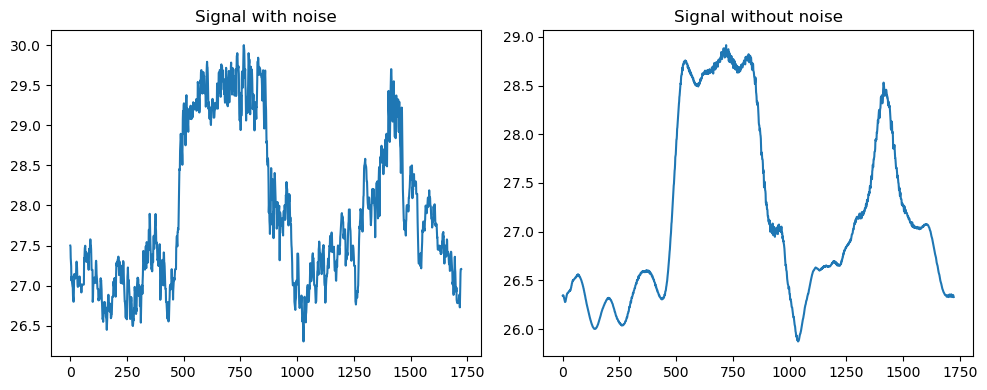

In [28]:
try:
    import pywt
    from statsmodels.robust import mad

    df = pd.read_csv(str(DATA_DIR / 'Temperature.csv'))
    print(df.head())

    def wp_denoise(frame):
        out = frame.copy()
        for column in out.columns:
            x = out[column].astype(float).values
            wp = pywt.WaveletPacket(data=x, wavelet='db7', mode='symmetric')
            new_wp = pywt.WaveletPacket(data=None, wavelet='db7', mode='sym')
            for level in range(wp.maxlevel):
                for node in [n.path for n in wp.get_level(level, 'natural')]:
                    sigma = mad(wp[node].data)
                    uthresh = sigma * np.sqrt(2 * np.log(len(wp[node].data)))
                    new_wp[node] = pywt.threshold(wp[node].data, value=uthresh, mode='soft')
            y = new_wp.reconstruct(update=False)[:len(x)]
            out[column] = y
        return out

    col = '4030CFDC'
    df_denoised = wp_denoise(df[[col]])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    df[col].plot(ax=axes[0], title='Signal with noise')
    df_denoised[col].plot(ax=axes[1], title='Signal without noise')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('Skipping — pip install PyWavelets statsmodels')


---

## Chapter 4 Summary

You covered **model diagnosis and tuning**: optimal probability cutoffs, imbalanced-data resampling, cross-validation, bagging/boosting ensembles, voting and stacking, hyperparameter search, and wavelet denoising.

**Next:** Chapter 5 — Text Analytics and NLP.
